In [59]:
# اول هنعرض المكتبات الاساسيه 
import pandas as pd        # لقراءة ومعالجه البيانات     
import numpy as np           # للعمليات الحسابية والمصفوفات  
import matplotlib.pyplot as plt     #تخصيص شكل وتصميم للرسومات البيانيه
import seaborn as sns                 #     


plt.style.use('fivethirtyeight')   # تجهيز شكل وتصميم الرسومات

import warnings                   # اخفاء تحذيرات
warnings.filterwarnings('ignore')   # لتجاهل التحذيرات غير الهامة    


In [60]:
data=pd.read_csv(r'C:\Users\mas\Downloads\Data kors sinc.csv')      

# Explore Data

In [61]:
data.head(2)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.5,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA


In [62]:
data.describe() # معمالات الحسابيه

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [63]:
data.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

<Axes: >

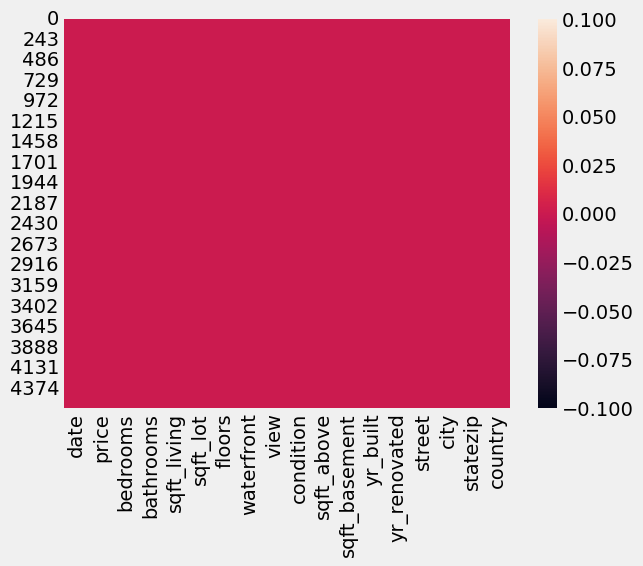

In [64]:
### هنا مفيش قيم مفقوده البيانات سليمه وهنعمل رسم بياني 
sns.heatmap(data.isnull())

# 2- Anlysis

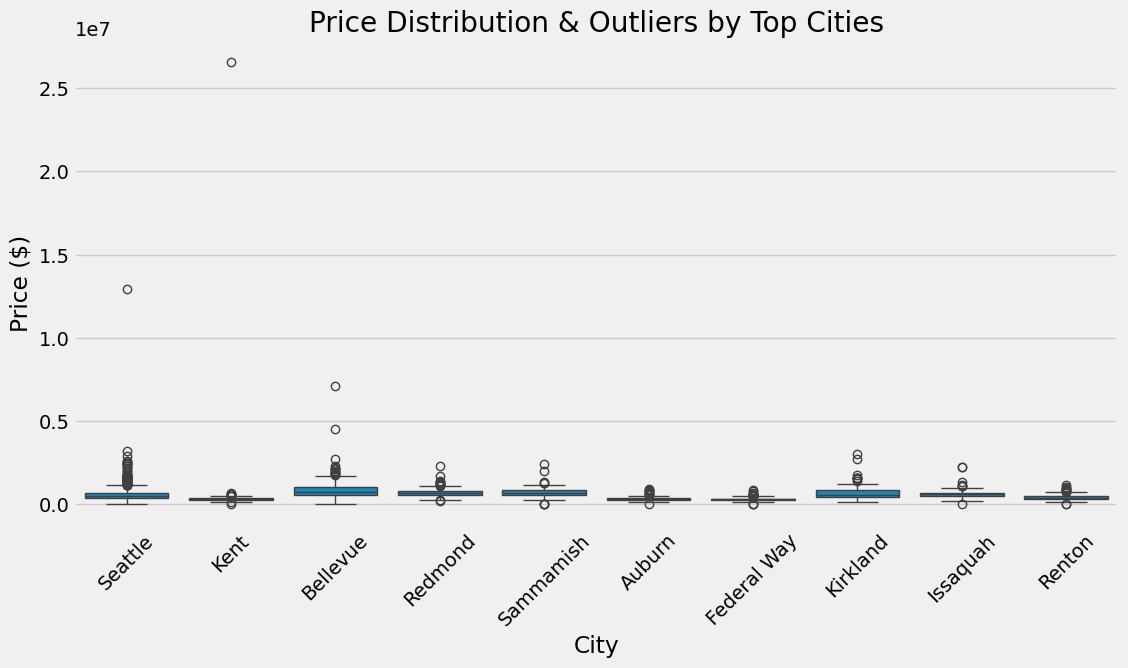

In [65]:

# 1. اختيار أكبر 10 مدن فيها عقارات لتجنب الزحمة
top_10_cities = data['city'].value_counts().head(10).index
subset = data[data['city'].isin(top_10_cities)]

# 2. رسم المخطط البصري
plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x='city', y='price')

plt.title('Price Distribution & Outliers by Top Cities')
plt.xticks(rotation=45)
plt.ylabel('Price ($)')
plt.xlabel('City')
plt.show()

In [66]:

# 1. دالة أوتوماتيكية تحسب وتنظف القيم الشاذة لكل مدينة بشكل مستقل
def clean_city_outliers(group):
    Q1 = group['price'].quantile(0.25)
    Q3 = group['price'].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + (1.5 * IQR)  # الحد الأعلى الطبيعي لأسعار المدينة

    # قص أي سعر شاذ يتجاوز حد المدينة الأقصى تلقائياً
    group['price'] = group['price'].clip(upper=upper_limit)
    return group


# 2. تطبيق الدالة على جميع مدن ومناطق الداتا بلمسة واحدة
data = data.groupby('city', group_keys=False).apply(clean_city_outliers)

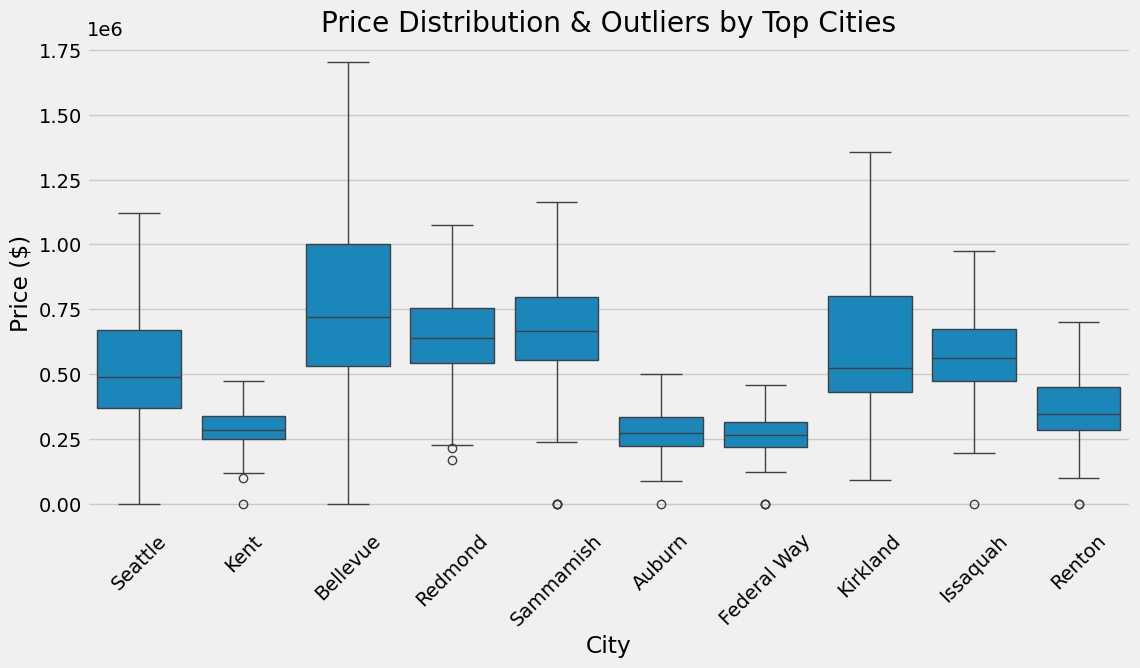

In [67]:

# 1. اختيار أكبر 10 مدن فيها عقارات لتجنب الزحمة
top_10_cities = data['city'].value_counts().head(10).index
subset = data[data['city'].isin(top_10_cities)]

# 2. رسم المخطط البصري
plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x='city', y='price')

plt.title('Price Distribution & Outliers by Top Cities')
plt.xticks(rotation=45)
plt.ylabel('Price ($)')
plt.xlabel('City')
plt.show()

In [68]:
# حساب لارتباط 
cor=data.corr(numeric_only=True)


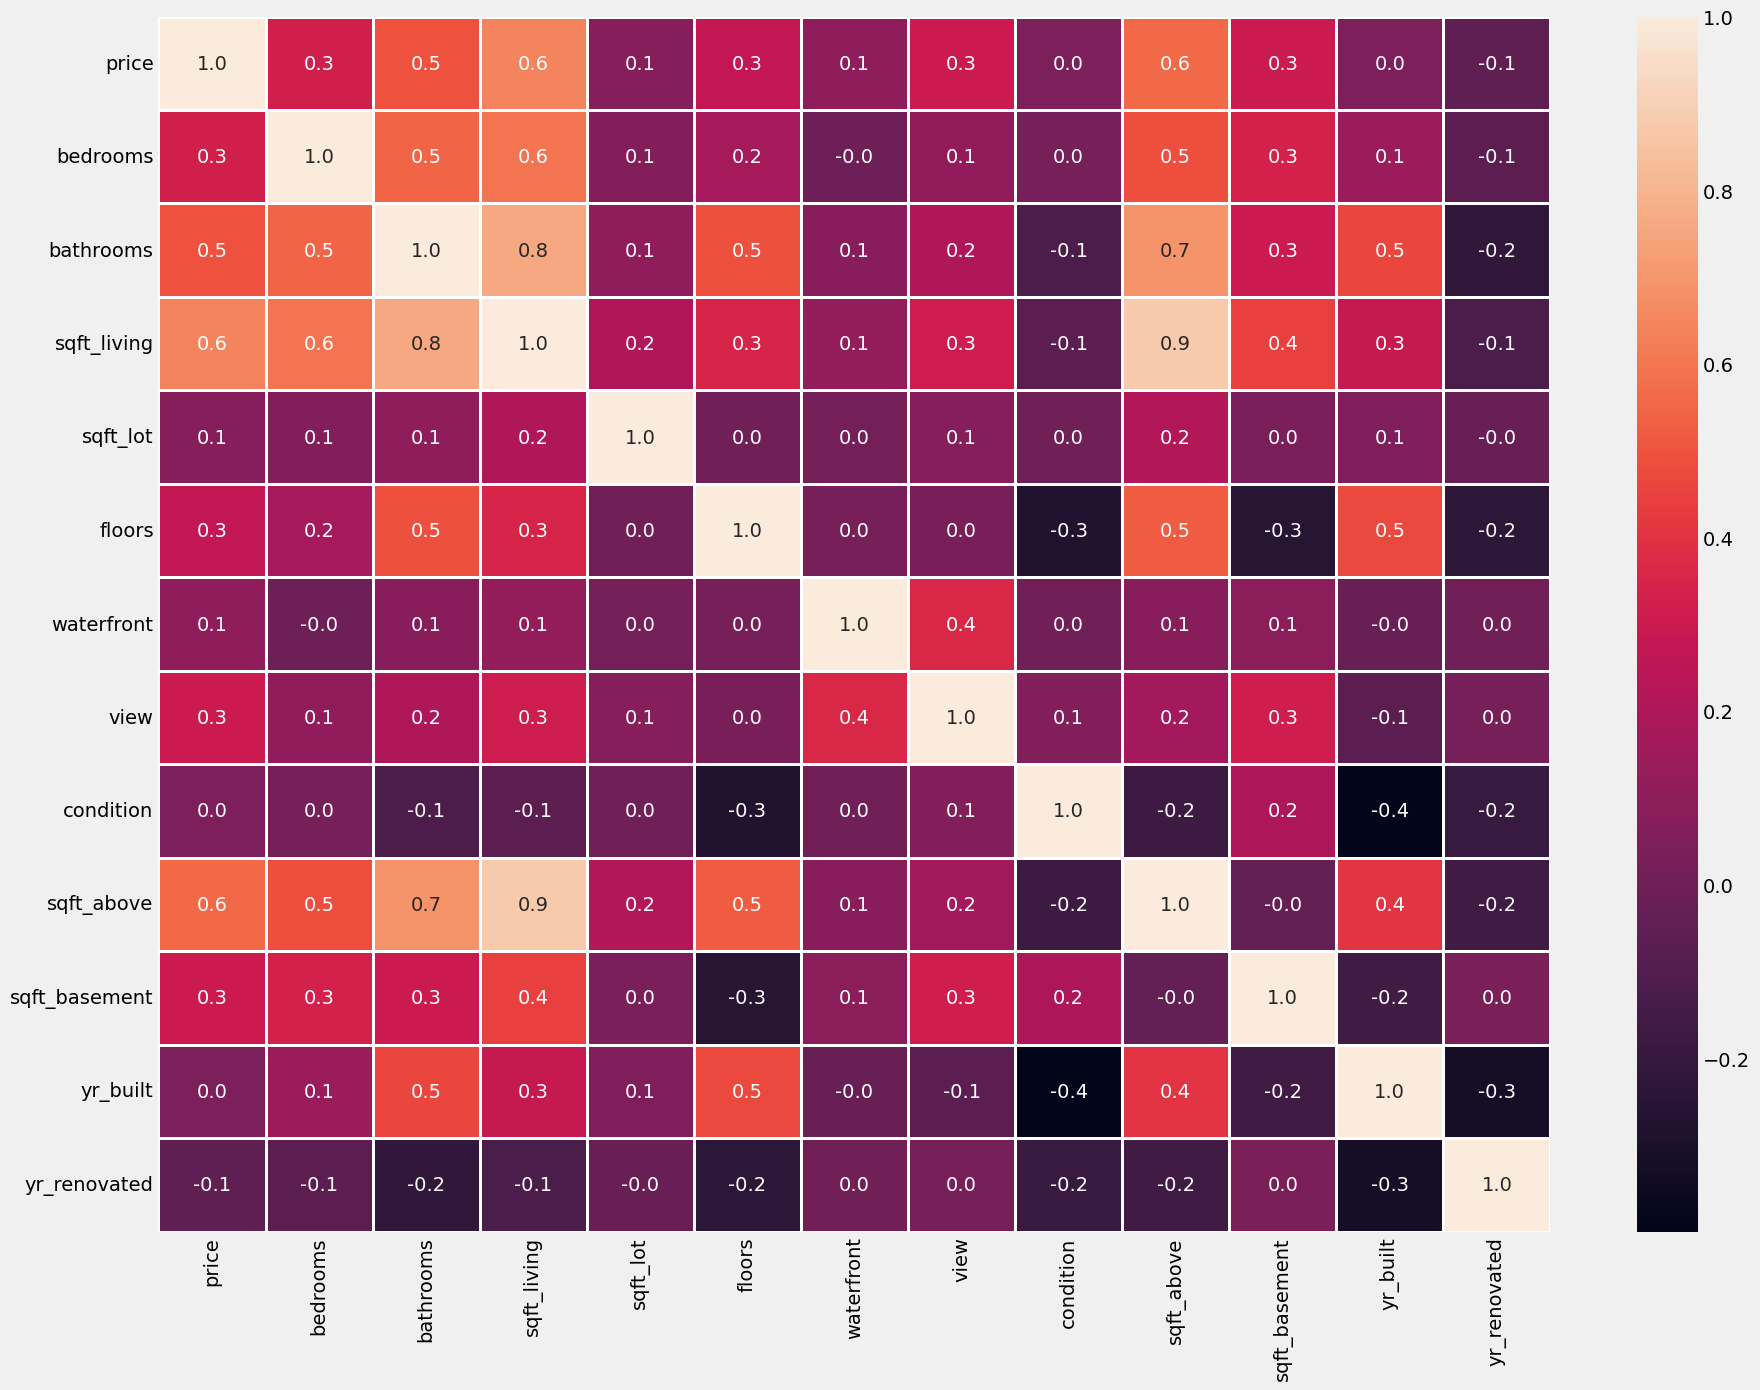

In [69]:
plt.figure(figsize=(20,15))
sns.heatmap(cor,linewidths='0.9',annot=True,fmt='.1f')
plt.show()

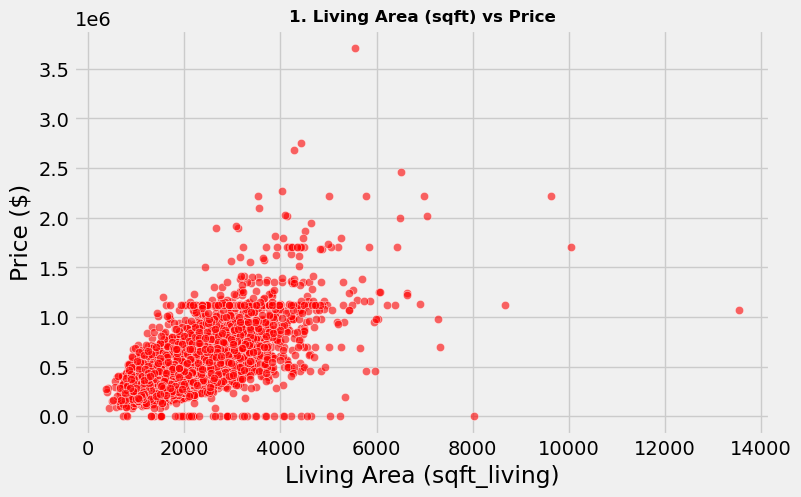

In [70]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='sqft_living', y='price', alpha=0.6, color='r')       # رسم مخطط  الانتشار
plt.title('1. Living Area (sqft) vs Price', fontsize=12, fontweight='bold')
plt.xlabel('Living Area (sqft_living)')
plt.ylabel('Price ($)')
plt.show()

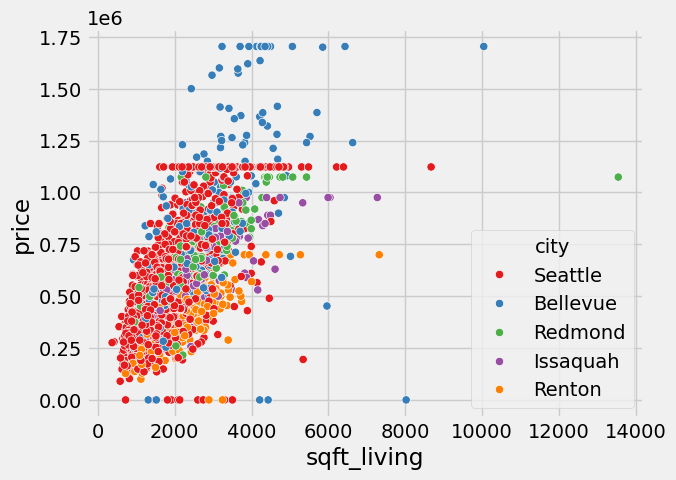

In [71]:

# 1. تحديد أعلى 5 مدن فقط
top5 = data['city'].value_counts().head(5).index

# 2. الرسم بألوان صريحة ومختلفة وسطر واحد للـ scatterplot
sns.scatterplot(
    data=data[data['city'].isin(top5)],
    x='sqft_living',
    y='price',
    hue='city',
    palette='Set1',
)
plt.show()

## 2. تأثير الإطلالة المائية على السعر (Waterfront View vs Price)
####  ما مدى فارق السعر بين العقارات المطلة على المياه والعقارات العادية؟
#### الاستنتاج:** العقارات التي تمتلك إطلالة مائية (`waterfront = 1`) يسجل متوسط أسرعارها ارتفاعاً كبيراً مقارنة بالعقارات الأخرى (`0`).


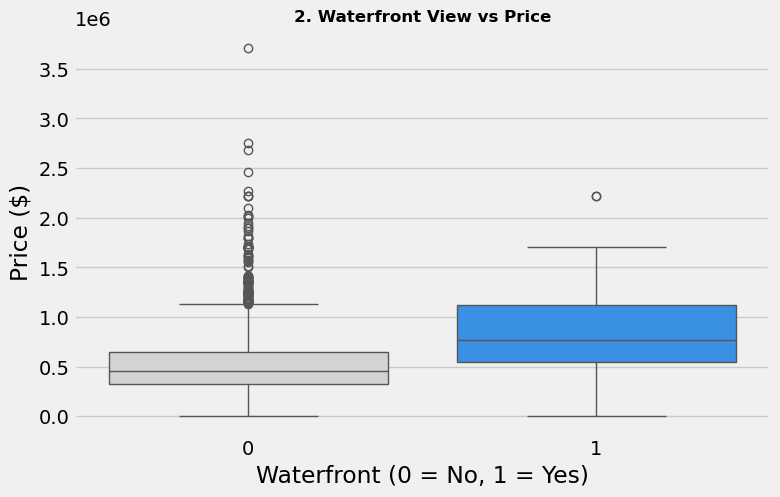

In [72]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='waterfront', y='price', hue='waterfront', palette=['lightgrey', 'dodgerblue'], legend=False)
plt.title('2. Waterfront View vs Price', fontsize=12, fontweight='bold')
plt.xlabel('Waterfront (0 = No, 1 = Yes)')
plt.ylabel('Price ($)')
plt.show()

In [73]:
# 1. حساب وسيط أسعار البيوت التي لا تطل على مياه
no_water_median = data[data['waterfront'] == 0]['price'].median()

# 2. استبدال الرقم الشاذ (الأكبر من 3 مليون) بالوسيط
data.loc[
    (data['waterfront'] == 0) & (data['price'] > 3000000), 'price'
] = no_water_median

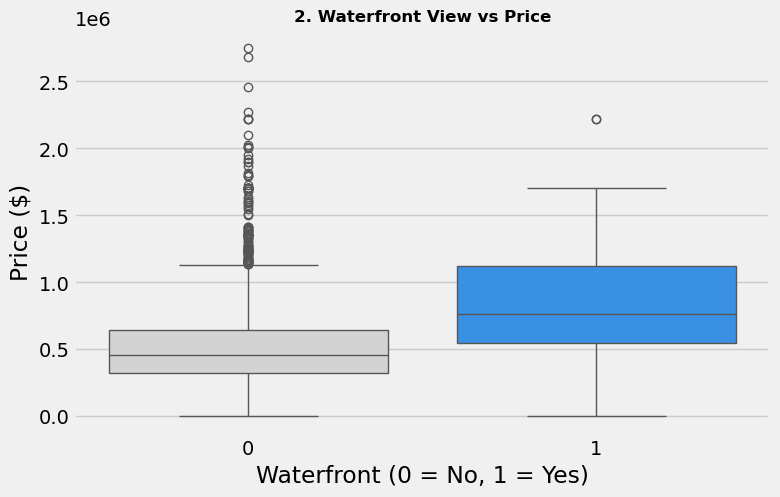

In [74]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='waterfront', y='price', hue='waterfront', palette=['lightgrey', 'dodgerblue'], legend=False)
plt.title('2. Waterfront View vs Price', fontsize=12, fontweight='bold')
plt.xlabel('Waterfront (0 = No, 1 = Yes)')
plt.ylabel('Price ($)')
plt.show()

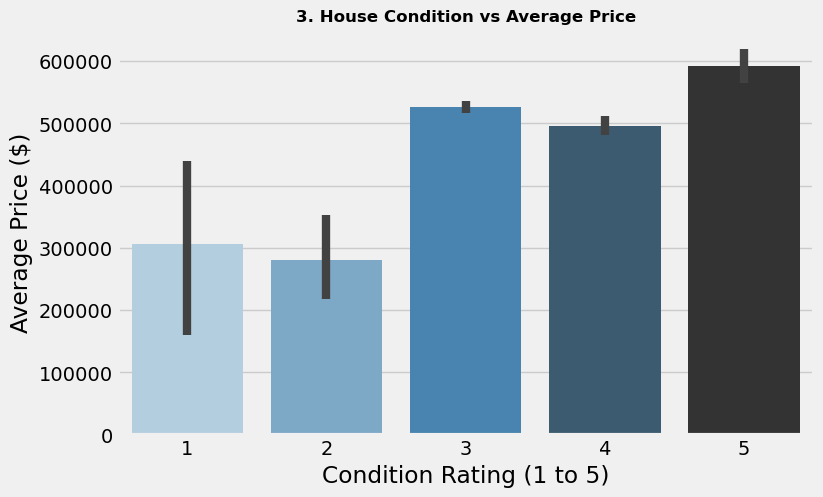

In [75]:
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x='condition', y='price', hue='condition', palette='Blues_d', legend=False)
plt.title('3. House Condition vs Average Price', fontsize=12, fontweight='bold')
plt.xlabel('Condition Rating (1 to 5)')
plt.ylabel('Average Price ($)')
plt.show()

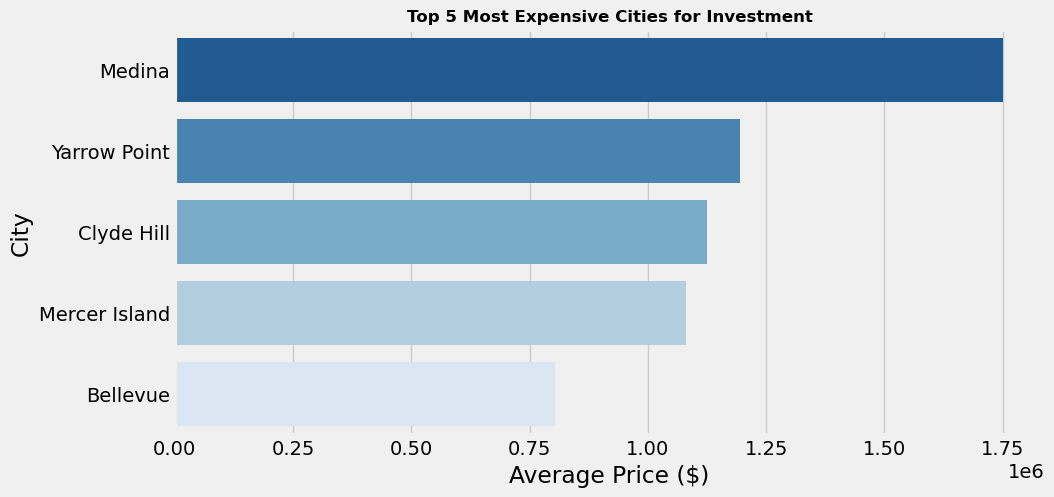

In [76]:

plt.figure(figsize=(10, 5))

# حساب متوسط الأسعار لكل مدينة واختيار أعلى 5 مدن
top_cities = data.groupby('city')['price'].mean().sort_values(ascending=False).head(5)

# رسم أعلى 5 مدن
sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')
plt.title('Top 5 Most Expensive Cities for Investment', fontsize=12, fontweight='bold')
plt.xlabel('Average Price ($)')
plt.ylabel('City')
plt.show()

In [77]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. توحيد المقاييس وتطبيق K-Means
scaled = StandardScaler().fit_transform(
    data[['price', 'sqft_living', 'condition']]
)
clusters = KMeans(n_clusters=3, random_state=42).fit_predict(scaled)

# 2. ترتيب التسميات تلقائياً من الأرخص للأغلى
data['Cluster'] = clusters
order = data.groupby('Cluster')['price'].mean().sort_values().index
mapping = {order[0]: 'Economy', order[1]: 'Mid-Range', order[2]: 'Luxury'}
data['Market Segment'] = data['Cluster'].map(mapping)

# 3. الرسم مباشرة


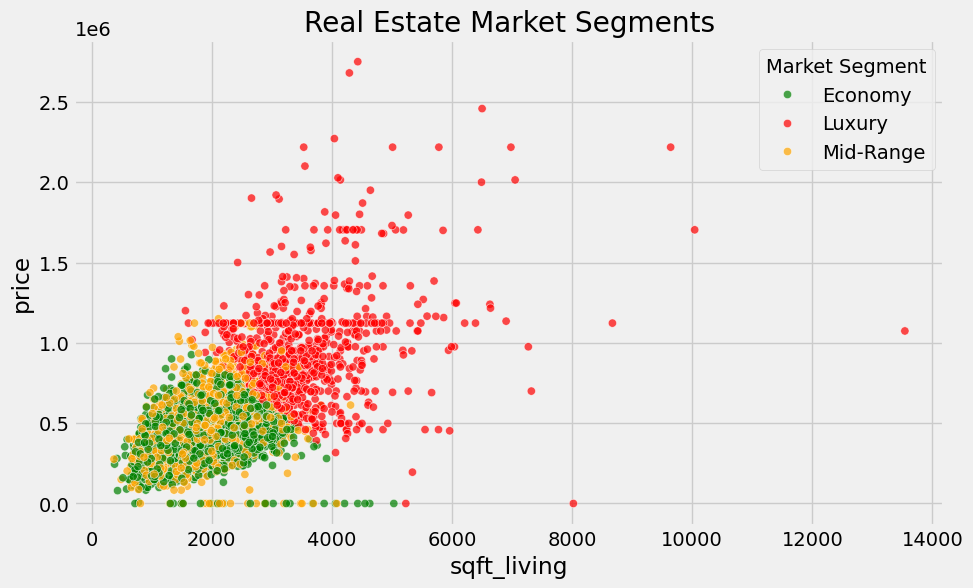

In [78]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data,
    x='sqft_living',
    y='price',
    hue='Market Segment',
    palette={'Economy': 'green', 'Mid-Range': 'orange', 'Luxury': 'red'},
    alpha=0.7,
)
plt.title('Real Estate Market Segments')
plt.show()

# 3- Data Processing

In [79]:
data=data.drop(['date'],axis=1)

In [80]:
data['statezip']=data['statezip'].str.replace('WA','')
data['statezip']=data['statezip'].astype(int)

In [81]:
dobject=data.select_dtypes(include='object')
dnumeric=data.select_dtypes(exclude='object')

In [82]:
from sklearn.preprocessing import LabelEncoder
al=LabelEncoder()

In [83]:
for i in range(0,dobject.shape[1]):
    dobject[dobject.columns[i]]=al.fit_transform(dobject.iloc[:,i])

In [84]:
data=pd.concat([dobject,dnumeric],axis=1)

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   street          4600 non-null   int64  
 1   city            4600 non-null   int64  
 2   country         4600 non-null   int64  
 3   Market Segment  4600 non-null   int64  
 4   price           4600 non-null   float64
 5   bedrooms        4600 non-null   float64
 6   bathrooms       4600 non-null   float64
 7   sqft_living     4600 non-null   int64  
 8   sqft_lot        4600 non-null   int64  
 9   floors          4600 non-null   float64
 10  waterfront      4600 non-null   int64  
 11  view            4600 non-null   int64  
 12  condition       4600 non-null   int64  
 13  sqft_above      4600 non-null   int64  
 14  sqft_basement   4600 non-null   int64  
 15  yr_built        4600 non-null   int64  
 16  yr_renovated    4600 non-null   int64  
 17  statezip        4600 non-null   int64 

In [86]:
data.head()

,street,city,country,Market Segment,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,statezip,Cluster
0,1522,36,0,0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,98133,1
1,3899,35,0,1,1122750.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,98119,0
2,2291,18,0,2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,98042,2
3,4263,3,0,2,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,98008,2
4,4352,31,0,2,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,98052,2


## هنا انا كده حولت النصوص كلها الى ارقام عشان ابتدي اشتغل علي الموديل

# 4- Model

In [87]:
# استبعاد العناوين والشرائح من الـ Features
data.drop(columns=['price', 'street', 'Cluster', 'Market Segment'])
#y = pd.get_dummies(x, columns=['city'], drop_first=True)

,city,country,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,statezip
0,36,0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,98133
1,35,0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,98119
2,18,0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,98042
3,3,0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,98008
4,31,0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,98052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,35,0,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,98133
4596,3,0,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,98007
4597,32,0,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,98059
4598,35,0,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,98178


In [88]:

# تحويل عمود المدن لعمود مستقل لكل مدينة (0 أو 1)
x= pd.get_dummies(data.drop(columns=['price']), columns=['city'], drop_first=True)
y= data['price']

In [89]:
from sklearn.model_selection import train_test_split


In [90]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)  #,random_state=)

In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

#   Nodel تقيم ومقياس  
from sklearn.metrics import mean_absolute_error,r2_score
                       


In [92]:
mode=RandomForestRegressor(n_estimators=200,random_state=42)

In [93]:
Algorithm=['LinearRegression','DecisionTreeRegressor','RandomForestRegressor','GradientBoostingRegressor','XGBRegressor']
R2=[]
Rmse=[]


In [94]:
model1=LinearRegression()
model2=DecisionTreeRegressor()
model3=RandomForestRegressor()
model4=GradientBoostingRegressor()
model5=XGBRegressor()

In [95]:
def models(model):
    model.fit(x_train,y_train)
    pre=model.predict(x_test)
    r2=r2_score(y_test,pre)
    rmse=np.sqrt(mean_absolute_error(y_test,pre))
    R2.append(r2)
    Rmse.append(rmse)
    score=model.score(x_test,y_test)
    print(f'The Scoce of Model i{score}')


In [96]:
models(model1)
models(model2)
models(model3)
models(model4)
models(model5)

The Scoce of Model i0.6627008321617287
The Scoce of Model i0.6146341003942873
The Scoce of Model i0.7319603367689685
The Scoce of Model i0.7113958182985769
The Scoce of Model i0.7061492583375526


In [97]:
df=pd.DataFrame({'Algorithm':Algorithm,'R2_Score':R2,'RMSE':Rmse})
df

,Algorithm,R2_Score,RMSE
0,LinearRegression,0.662701,325.408213
1,DecisionTreeRegressor,0.614634,333.533351
2,RandomForestRegressor,0.731960,299.840714
3,GradientBoostingRegressor,0.711396,319.011355
4,XGBRegressor,0.706149,295.682523


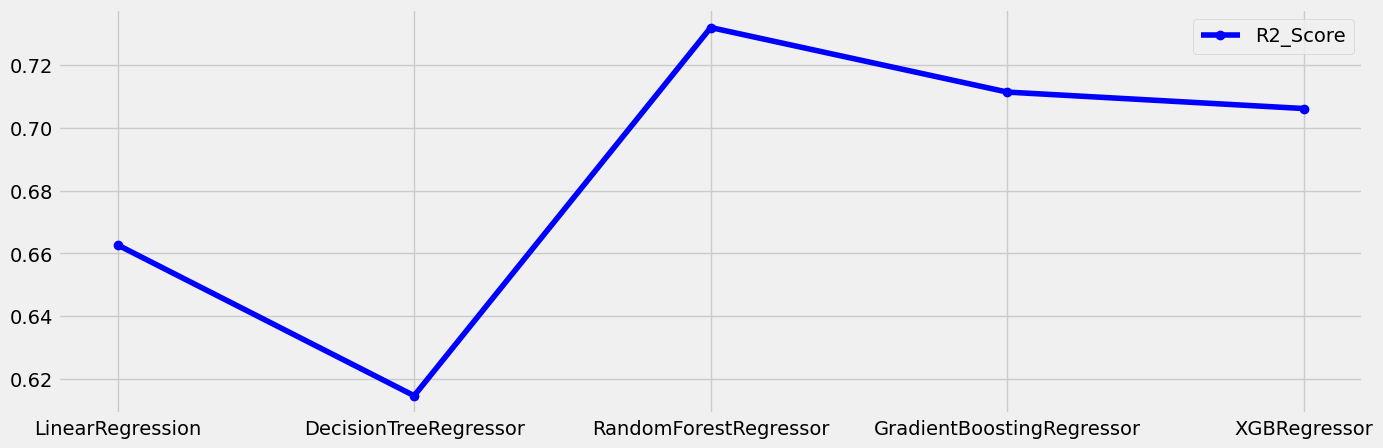

In [98]:
fig,ax=plt.subplots(figsize=(15,5))
plt.plot(df.Algorithm,df.R2_Score,label='R2_Score',c='b',marker='o')
plt.legend()
plt.show()

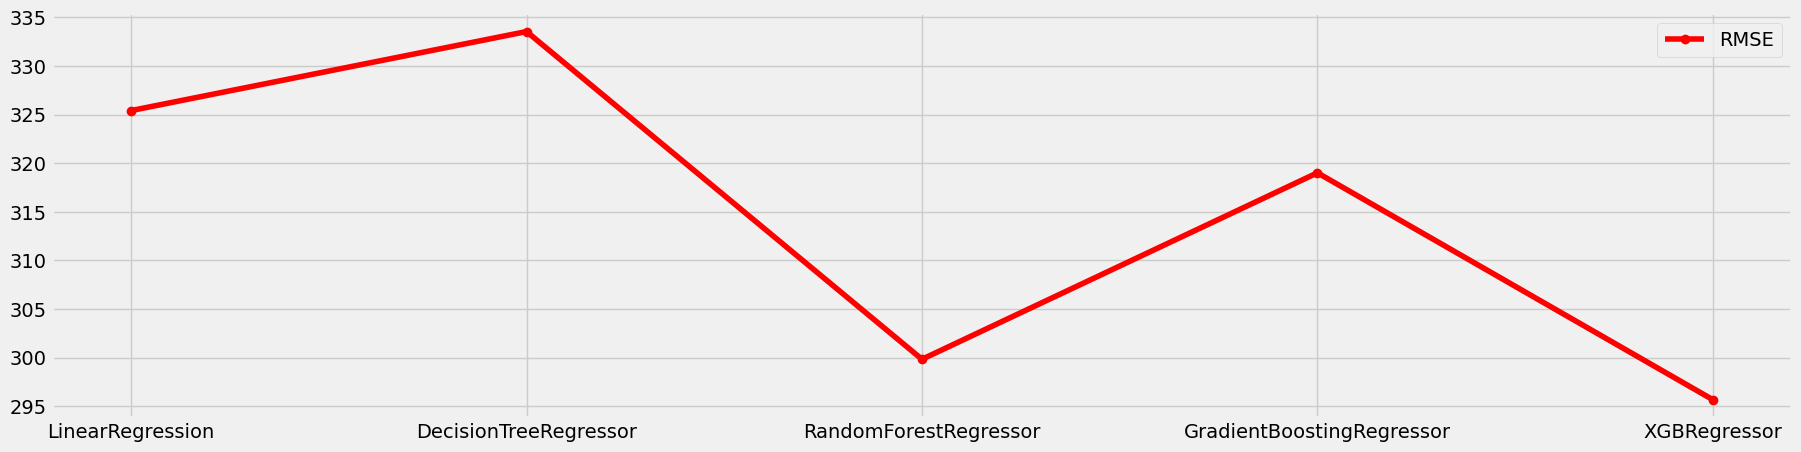

In [99]:
fit,sx=plt.subplots(figsize=(20,5))
plt.plot(df.Algorithm,df.RMSE,label='RMSE',c='r',marker='o')
plt.legend()
plt.show()

In [100]:
# 1. تدريب وتوقع مباشر
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

preds = rf_model.predict(x_test)

# 2. إنشاء الجدول مباشرة من y_test و preds بدون متغيرات خارجية
comparison_df = pd.DataFrame(
    {'Actual Price ($)': y_test.values[:10], 'Predicted Price ($)': preds[:10]}
)

display(comparison_df)

,Actual Price ($),Predicted Price ($)
0,5.440000e+05,4.458341e+05
1,0.000000e+00,3.058963e+05
2,1.122750e+06,1.095372e+06
3,3.650000e+05,4.335336e+05
4,2.750000e+05,2.451692e+05
5,6.125000e+05,4.972136e+05
6,4.530000e+05,5.249359e+05
7,3.000000e+05,2.723333e+05
8,4.179857e+05,5.842108e+05
9,6.725000e+05,8.216478e+05


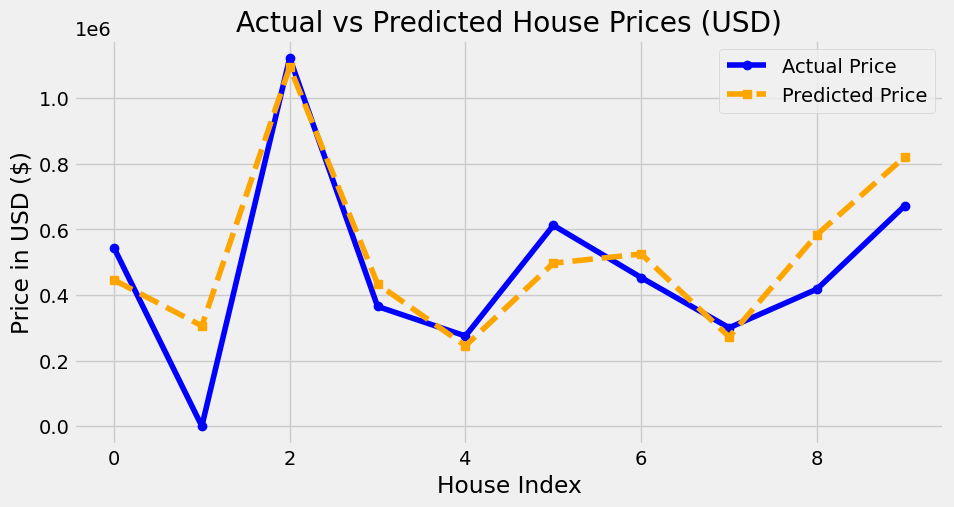

In [101]:

# 3. رسم البياني المضبوط والمطابق للأرقام
plt.figure(figsize=(10, 5))
plt.plot(comparison_df['Actual Price ($)'], marker='o', label='Actual Price', color='blue')
plt.plot(comparison_df['Predicted Price ($)'], marker='s', linestyle='--', label='Predicted Price', color='orange')
plt.title('Actual vs Predicted House Prices (USD)')
plt.xlabel('House Index')
plt.ylabel('Price in USD ($)')
plt.legend()
plt.grid(True)
plt.show()

# 5-Using My Model To Prebict New Data

In [102]:
import pickle        # مكتبه بتخلينا نحفظ داتا نقدر نستدعيها  تاني لو نستخدمها   فى بالكيشن او حاجه تاني

In [103]:
file_name='house_price_calulator.sav'

In [104]:
pickle.dump(model2,open(file_name,'wb'))